In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Load dataset
DATA_PATH = "/content/address_data_combined_ts.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
pd.set_option("display.max_columns", None)
display(df.head(10))

Shape: (13920, 24)


,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Unique Received From Addresses,min value received,max value received,avg val received,min val sent,avg val sent,total transactions (including tnx to create contract,total ether received,total ether balance,adjusted_eth_value__absolute_sum_of_changes,adjusted_eth_value__mean_abs_change,adjusted_eth_value__energy_ratio_by_chunks__num_segments_10__segment_focus_0,adjusted_eth_value__sum_values,adjusted_eth_value__abs_energy,adjusted_eth_value__ratio_value_number_to_time_series_length,adjusted_eth_value__quantile__q_0.1,adjusted_eth_value__count_below__t_0,adjusted_eth_value__count_above__t_0,adjusted_eth_value__median
0,0x87d884aaa6ff9e9b6014631b0abae80b53953fb8,1,5151.68,15159.08,71235.62,1,0.010000,0.020000,0.013367,0.000000,0.000000,8,0.040100,0.040100,0.129900,0.008119,0.358576,0.032100,0.001400,0.470588,0.000000,0.647059,0.941176,0.000000
1,0xd42393df90d582bd8a5493171f0173e3a017d391,1,1179.02,1124.89,25126.45,13,0.000000,0.750000,0.176667,0.145000,0.419270,22,2.650000,-0.284889,7.669778,0.365228,0.020237,-0.284889,3.335466,0.409091,-0.267421,0.363636,0.681818,0.150000
2,0x3025c36d8a9620d3df89e9e9b1acbdfd639a6f37,1,361.73,0.00,723.47,1,4.999916,4.999916,4.999916,2.490000,2.499538,3,4.999916,0.000840,7.508992,3.754496,0.666738,0.000840,37.494722,1.000000,-2.505261,0.666667,0.333333,-2.490000
3,0x6309f709faad518fc158af4c14edfa7b06424770,1,0.00,0.00,0.00,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0x3d020954e30c3d40b7f0c533cf198bc10dd45a49,1,14280.60,1479.86,45357.57,21,0.035000,0.200000,0.099286,2.084658,2.084658,22,2.085000,0.000342,3.404658,0.162127,0.006660,0.000342,4.594823,0.409091,0.050000,0.045455,0.954545,0.085000
5,0xb300f2a0fa449b97a1069ea7ad654aca486f64b5,1,0.00,0.00,0.00,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0x83915e4ff807ba28b53931f923247c9fa0147eb9,1,212.63,59.16,3746.00,12,0.000008,0.317522,0.037252,0.000000,0.937929,27,0.484270,-12.646730,20.698217,0.796085,0.000011,-12.646730,103.123884,0.629630,-1.000000,0.518519,0.814815,0.000000
7,0x0f38DAeCb3FB7b87A8d3ED168822c1bC53e8202C,1,0.00,0.00,0.00,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,301.479126,8.867033,0.319055,191.506779,4734.369331,0.628571,0.202559,0.057143,1.000000,0.820000
8,0xcc320aa1fe572798a1f900cfa0df6524b04c9624,1,0.00,0.00,0.00,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,1.000000,1.000000,0.000000
9,0xe7860fd151cbbad28141dfd4cc7cd6d090e4ead8,1,0.00,0.00,0.00,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,29.400000,3.675000,0.000000,33.851432,305.463827,0.777778,0.160000,0.111111,1.000000,1.134324


In [ ]:
#Basic EDA
print("\nColumns and dtypes")
print(df.dtypes)
print("\nMissing values per column")
print(df.isnull().sum())


Columns and dtypes
Address                                                                          object
FLAG                                                                              int64
Avg min between sent tnx                                                        float64
Avg min between received tnx                                                    float64
Time Diff between first and last (Mins)                                         float64
Unique Received From Addresses                                                    int64
min value received                                                              float64
max value received                                                              float64
avg val received                                                                float64
min val sent                                                                    float64
avg val sent                                                                    float64
total transa

In [ ]:
# Check label distribution
if 'FLAG' in df.columns:
    print("\nFraud label distribution (FLAG)")
    counts = df['FLAG'].value_counts()
    total = len(df)
    percents = (counts / total * 100).round(2)
    summary = pd.DataFrame({'Count': counts, 'Percent (%)': percents})
    print(summary)


Fraud label distribution (FLAG)
      Count  Percent (%)
FLAG                    
0      7637        54.86
1      6283        45.14


There are no missing values and the dataset is quite balanced.

# **Objective 1: To identify the characteristics of fraudulent cryptocurrency wallets based on transaction features.**

# **Descriptive Statistics of both targets**

In [ ]:
# Split dataset by FLAG
fraud_df = df[df['FLAG'] == 1]
nonfraud_df = df[df['FLAG'] == 0]

# List of numeric features excluding Address and FLAG
numeric_features = df.select_dtypes(include='number').columns.tolist()
numeric_features.remove('FLAG')

# Compute descriptive statistics for fraud accounts
fraud_stats = fraud_df[numeric_features].describe().T  # Transpose for readability

# Compute descriptive statistics for non-fraud accounts
nonfraud_stats = nonfraud_df[numeric_features].describe().T

# Combine into a single table for comparison
comparison_stats = fraud_stats[['mean','50%','std','min','max']].rename(
    columns={'50%':'median','std':'std_dev'}
).join(
    nonfraud_stats[['mean','50%','std','min','max']].rename(
        columns={'mean':'nonfraud_mean','50%':'nonfraud_median','std':'nonfraud_std','min':'nonfraud_min','max':'nonfraud_max'}
    )
)

# Display table
comparison_stats

,mean,median,std_dev,min,max,nonfraud_mean,nonfraud_median,nonfraud_std,nonfraud_min,nonfraud_max
Avg min between sent tnx,1.170318e+04,97.710000,5.925190e+04,0.000000,1.461535e+06,5.419365e+03,22.750000,2.248232e+04,0.000000e+00,4.302877e+05
Avg min between received tnx,4.316816e+03,65.140000,2.115548e+04,0.000000,5.171611e+05,9.461692e+03,1403.400000,2.534831e+04,0.000000e+00,4.821755e+05
Time Diff between first and last (Mins),1.066567e+05,8054.730000,2.714100e+05,0.000000,2.837470e+06,2.646823e+05,116874.320000,3.477819e+05,0.000000e+00,1.954861e+06
Unique Received From Addresses,2.096753e+01,3.000000,1.545492e+02,0.000000,9.581000e+03,3.554511e+01,2.000000,3.367784e+02,0.000000e+00,9.999000e+03
min value received,1.932626e+01,0.003515,4.683777e+02,0.000000,2.553361e+04,4.758111e+01,0.156190,2.345300e+02,0.000000e+00,1.000000e+04
max value received,4.769367e+01,0.880000,6.394815e+02,0.000000,2.553361e+04,6.583241e+02,12.228277,1.475973e+04,0.000000e+00,8.000000e+05
avg val received,2.651725e+01,0.291309,4.899759e+02,0.000000,2.553361e+04,1.190383e+02,3.750000,3.261149e+03,0.000000e+00,2.836188e+05
min val sent,7.568128e+00,0.000000,1.221031e+02,0.000000,7.204900e+03,4.321082e+00,0.056000,1.458048e+02,0.000000e+00,1.200000e+04
avg val sent,1.655676e+01,0.461319,2.542258e+02,0.000000,1.276681e+04,5.272600e+01,2.309629,2.288513e+02,0.000000e+00,1.200000e+04
total transactions (including tnx to create contract,4.955992e+01,7.000000,2.927606e+02,0.000000,1.000000e+04,3.566438e+02,11.000000,1.521218e+03,1.000000e+00,1.999500e+04


In [ ]:
# Create a new table for differences
diff_stats = pd.DataFrame(index=fraud_stats.index)

# Compute differences (absolute)
diff_stats['mean_diff'] = abs(fraud_stats['mean'] - nonfraud_stats['mean'])
diff_stats['median_diff'] = abs(fraud_stats['50%'] - nonfraud_stats['50%'])  # 50% is median in describe()
diff_stats['std_diff'] = abs(fraud_stats['std'] - nonfraud_stats['std'])
diff_stats['min_diff'] = abs(fraud_stats['min'] - nonfraud_stats['min'])
diff_stats['max_diff'] = abs(fraud_stats['max'] - nonfraud_stats['max'])

# Sort by mean_diff to spot largest differences
diff_stats = diff_stats.sort_values(by='mean_diff', ascending=False)

# Display top 10 features with largest differences
diff_stats.head(10)

,mean_diff,median_diff,std_diff,min_diff,max_diff
adjusted_eth_value__abs_energy,6.834265e+08,842.684981,2.292905e+10,0.000000e+00,1.168696e+12
Time Diff between first and last (Mins),1.580256e+05,108819.590000,7.637190e+04,0.000000e+00,8.826090e+05
adjusted_eth_value__absolute_sum_of_changes,3.303993e+04,135.949894,6.797628e+05,0.000000e+00,2.810293e+07
total ether received,1.488076e+04,69.713809,4.124015e+05,0.000000e+00,2.853811e+07
Avg min between sent tnx,6.283812e+03,74.960000,3.676958e+04,0.000000e+00,1.031248e+06
Avg min between received tnx,5.144876e+03,1338.260000,4.192838e+03,0.000000e+00,3.498561e+04
total ether balance,1.921788e+03,0.001717,2.741296e+05,1.553533e+07,1.427564e+07
max value received,6.106304e+02,11.348277,1.412025e+04,0.000000e+00,7.744664e+05
adjusted_eth_value__sum_values,4.252888e+02,0.001139,3.245613e+05,1.553543e+07,1.423751e+07
total transactions (including tnx to create contract,3.070839e+02,4.000000,1.228458e+03,1.000000e+00,9.995000e+03


In [ ]:
# Define top 10 features
top_features = [
    'adjusted_eth_value__abs_energy',
    'Time Diff between first and last (Mins)',
    'adjusted_eth_value__absolute_sum_of_changes',
    'total ether received',
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'total ether balance',
    'max value received ',
    'adjusted_eth_value__sum_values',
    'total transactions (including tnx to create contract'
]

# Filter comparison_stats for top features
top_comparison = comparison_stats.loc[comparison_stats.index.isin(top_features)].copy()

# Mapping of fraud stats to corresponding non-fraud columns
stat_map = {
    'mean': 'nonfraud_mean',
    'median': 'nonfraud_median',
    'std_dev': 'nonfraud_std',
    'min': 'nonfraud_min',
    'max': 'nonfraud_max'
}

# Add columns indicating which class has higher values
for stat, nonfraud_col in stat_map.items():
    top_comparison[f'{stat}_higher'] = top_comparison.apply(
        lambda row: 'Fraud' if row[stat] > row[nonfraud_col] else 'Non-fraud',
        axis=1
    )

# Optional: compute mean difference for sorting
top_comparison['mean_diff'] = abs(top_comparison['mean'] - top_comparison['nonfraud_mean'])
top_comparison = top_comparison.sort_values(by='mean_diff', ascending=False)

# Reset index for display
top_comparison.reset_index(inplace=True)
top_comparison

,index,mean,median,std_dev,min,max,nonfraud_mean,nonfraud_median,nonfraud_std,nonfraud_min,nonfraud_max,mean_higher,median_higher,std_dev_higher,min_higher,max_higher,mean_diff
0,adjusted_eth_value__abs_energy,1.420267e+06,6.584003,3.302210e+07,0.00000,1.303931e+09,6.848467e+08,849.268984,2.296207e+10,0.00,1.170000e+12,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Non-fraud,6.834265e+08
1,Time Diff between first and last (Mins),1.066567e+05,8054.730000,2.714100e+05,0.00000,2.837470e+06,2.646823e+05,116874.320000,3.477819e+05,0.00,1.954861e+06,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Fraud,1.580256e+05
2,adjusted_eth_value__absolute_sum_of_changes,2.736713e+02,5.759514,2.951914e+03,0.00000,1.121262e+05,3.331360e+04,141.709408,6.827147e+05,0.00,2.821505e+07,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Non-fraud,3.303993e+04
3,total ether received,8.645217e+01,1.953640,9.759760e+02,0.00000,4.347946e+04,1.496722e+04,71.667449,4.133775e+05,0.00,2.858159e+07,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Non-fraud,1.488076e+04
4,Avg min between sent tnx,1.170318e+04,97.710000,5.925190e+04,0.00000,1.461535e+06,5.419365e+03,22.750000,2.248232e+04,0.00,4.302877e+05,Fraud,Fraud,Fraud,Non-fraud,Fraud,6.283812e+03
5,Avg min between received tnx,4.316816e+03,65.140000,2.115548e+04,0.00000,5.171611e+05,9.461692e+03,1403.400000,2.534831e+04,0.00,4.821755e+05,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Fraud,5.144876e+03
6,total ether balance,-2.080921e+01,0.000483,1.063988e+03,-70019.91495,1.299146e+04,1.900979e+03,0.002200,2.751936e+05,-15605352.04,1.428864e+07,Non-fraud,Non-fraud,Non-fraud,Fraud,Non-fraud,1.921788e+03
7,max value received,4.769367e+01,0.880000,6.394815e+02,0.00000,2.553361e+04,6.583241e+02,12.228277,1.475973e+04,0.00,8.000000e+05,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Non-fraud,6.106304e+02
8,adjusted_eth_value__sum_values,-1.408161e+00,0.000861,1.395053e+03,-70019.77990,5.112494e+04,-4.266970e+02,0.002000,3.259564e+05,-15605453.04,1.428864e+07,Fraud,Non-fraud,Non-fraud,Fraud,Non-fraud,4.252888e+02
9,total transactions (including tnx to create co...,4.955992e+01,7.000000,2.927606e+02,0.00000,1.000000e+04,3.566438e+02,11.000000,1.521218e+03,1.00,1.999500e+04,Non-fraud,Non-fraud,Non-fraud,Non-fraud,Non-fraud,3.070839e+02


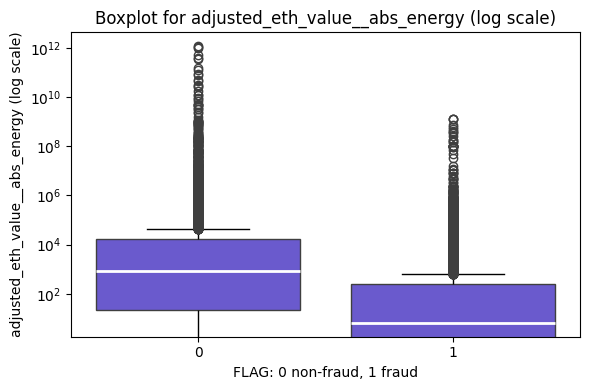

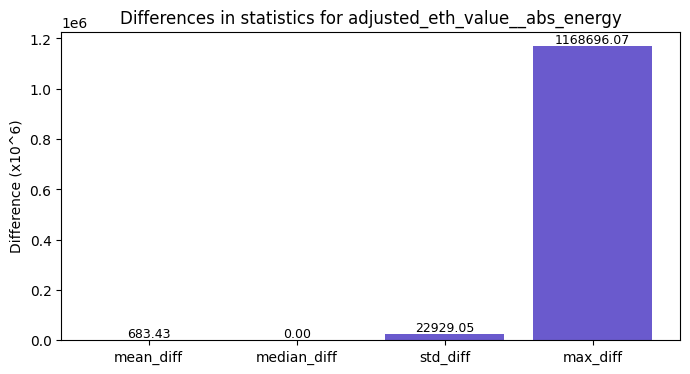

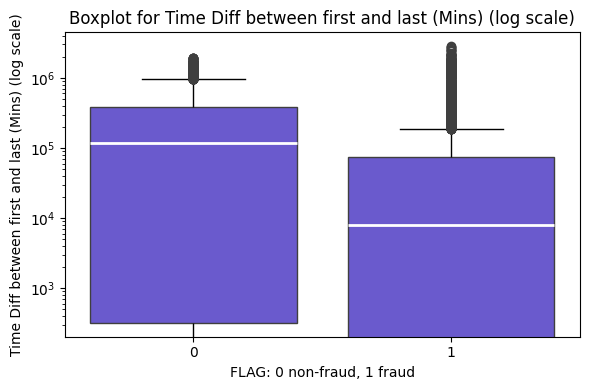

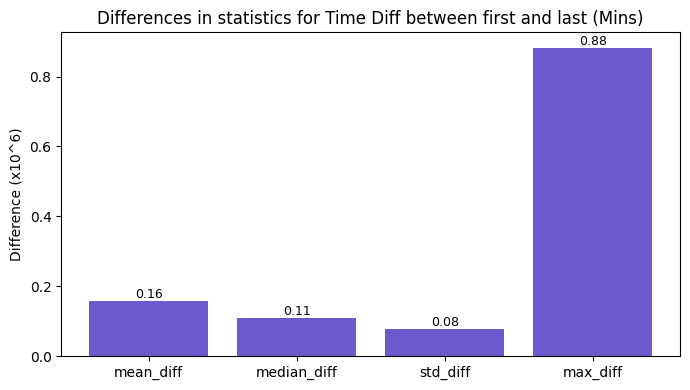

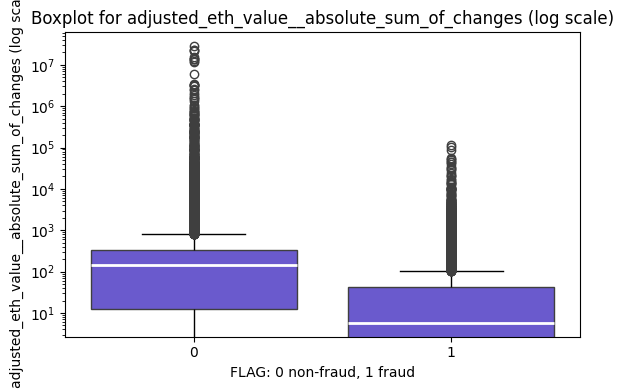

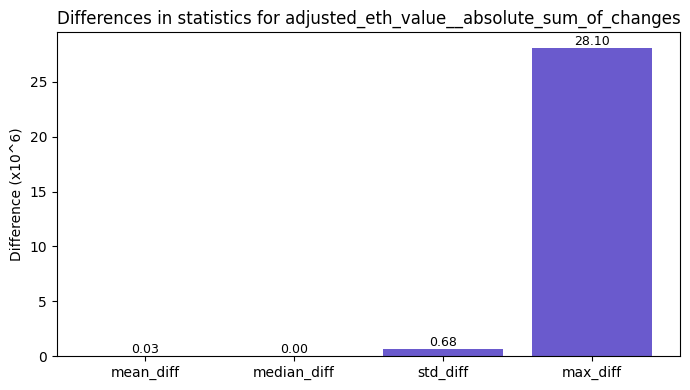

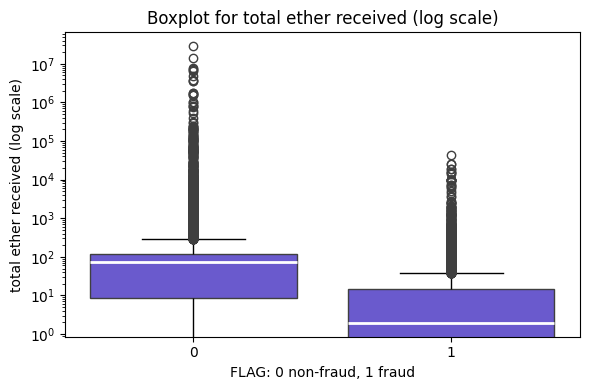

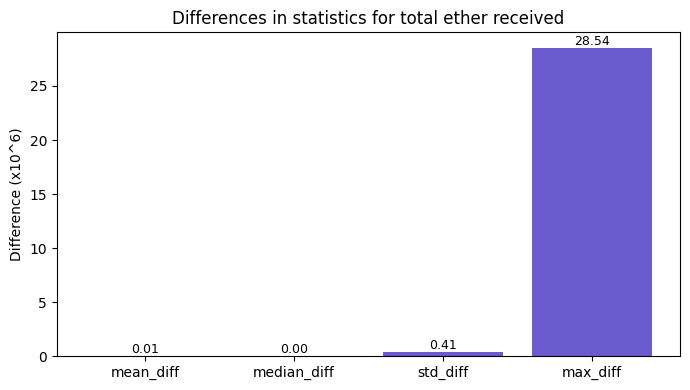

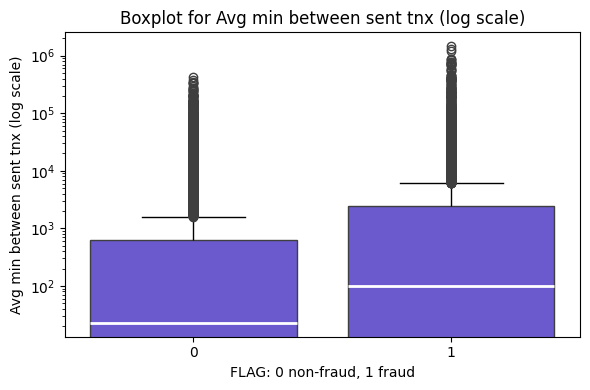

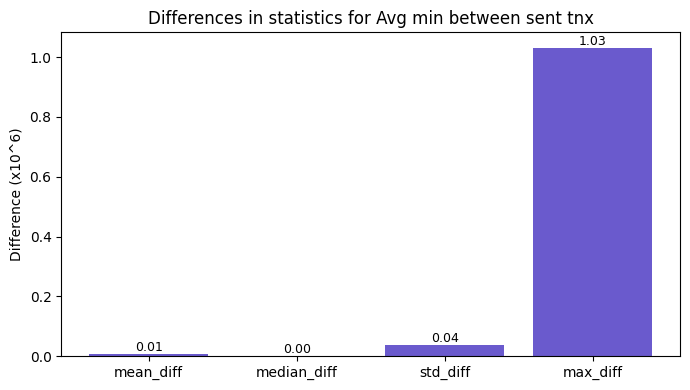

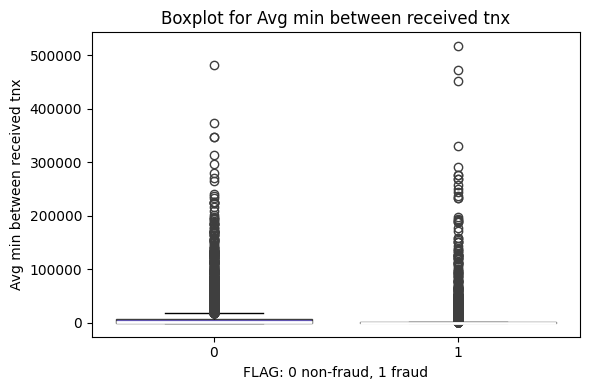

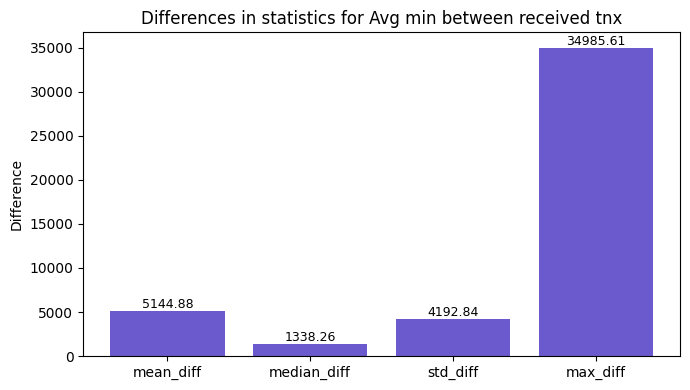

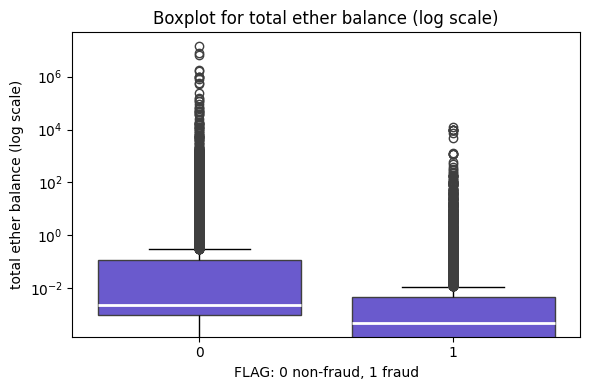

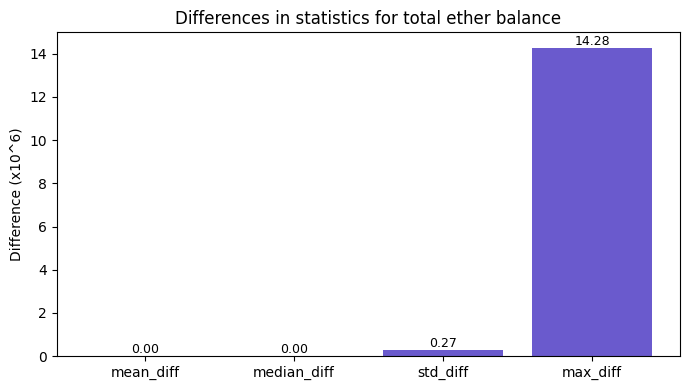

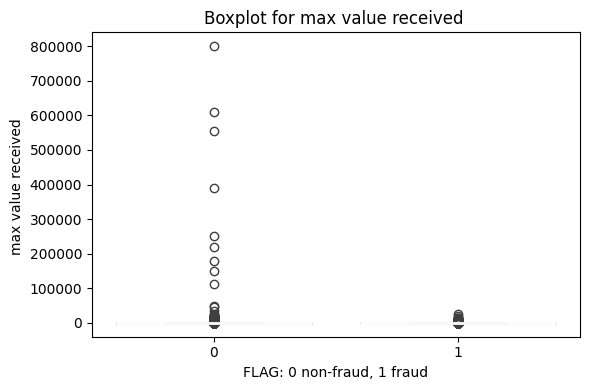

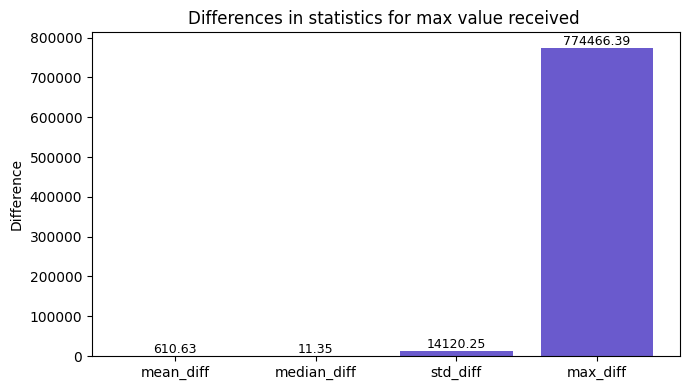

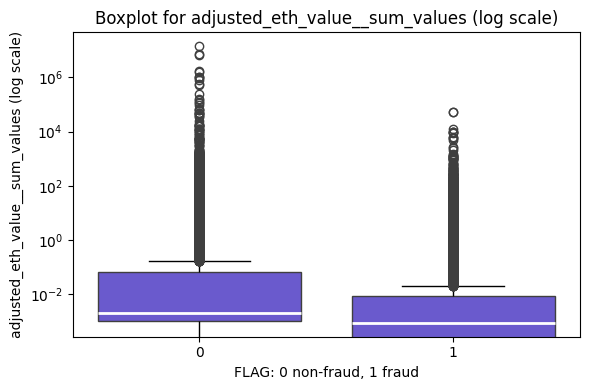

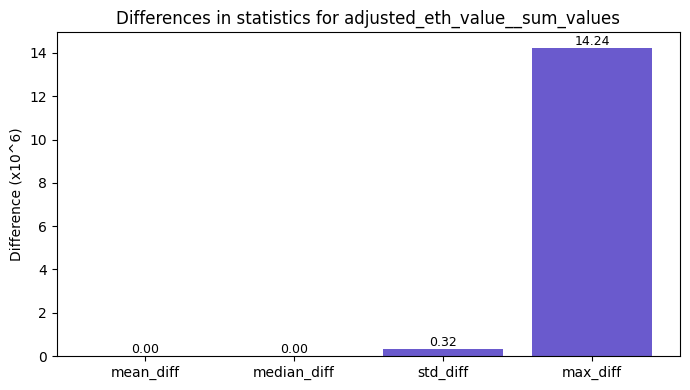

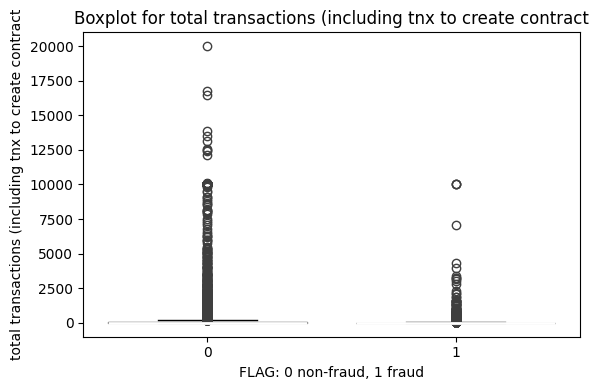

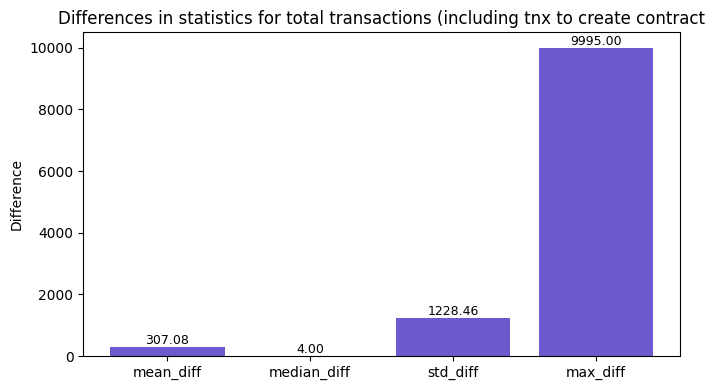

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

top_features = [
    'adjusted_eth_value__abs_energy',
    'Time Diff between first and last (Mins)',
    'adjusted_eth_value__absolute_sum_of_changes',
    'total ether received',
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'total ether balance',
    'max value received ',
    'adjusted_eth_value__sum_values',
    'total transactions (including tnx to create contract'
]

%matplotlib inline

fraud = df[df['FLAG'] == 1]
nonfraud = df[df['FLAG'] == 0]

fraud_stats = fraud.describe().T
nonfraud_stats = nonfraud.describe().T

def plot_feature_slide(feature):
    # ---------------------
    # Boxplot
    # ---------------------
    plt.figure(figsize=(6,4))

    max_val = df[feature].max()
    use_log = max_val > 1e6  # threshold for log scale

    sns.boxplot(
        data=df,
        x='FLAG',
        y=feature,
        boxprops=dict(facecolor='slateblue'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        medianprops=dict(color='white', linewidth=2)
    )
    if use_log:
        plt.yscale('log')

    plt.title(f'Boxplot for {feature}' + (' (log scale)' if use_log else ''))
    plt.xlabel('FLAG: 0 non-fraud, 1 fraud')
    plt.ylabel(feature + (' (log scale)' if use_log else ''))
    plt.tight_layout()
    plt.show()

    # ---------------------
    # Bar plot for differences
    # ---------------------
    mean_diff = abs(fraud_stats.loc[feature, 'mean'] - nonfraud_stats.loc[feature, 'mean'])
    median_diff = abs(fraud_stats.loc[feature, '50%'] - nonfraud_stats.loc[feature, '50%'])
    std_diff = abs(fraud_stats.loc[feature, 'std'] - nonfraud_stats.loc[feature, 'std'])
    max_diff = abs(fraud_stats.loc[feature, 'max'] - nonfraud_stats.loc[feature, 'max'])

    # Auto-scale for readability
    scale_factor = 1e6 if max_val > 1e6 else 1

    diff_data = {
        'mean_diff': mean_diff / scale_factor,
        'median_diff': median_diff / scale_factor,
        'std_diff': std_diff / scale_factor,
        'max_diff': max_diff / scale_factor
    }

    plt.figure(figsize=(7,4))
    bars = plt.bar(diff_data.keys(), diff_data.values(), color=['slateblue'])
    plt.title(f'Differences in statistics for {feature}')
    plt.ylabel(f'Difference' + (f' (x10^6)' if scale_factor>1 else ''))

    # Add labels above bars with 2 decimals
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

# Loop through all top features
for f in top_features:
    try:
        plot_feature_slide(f)
    except Exception as e:
        print(f"Error plotting {f}: {e}")


# **Correlation Analysis**

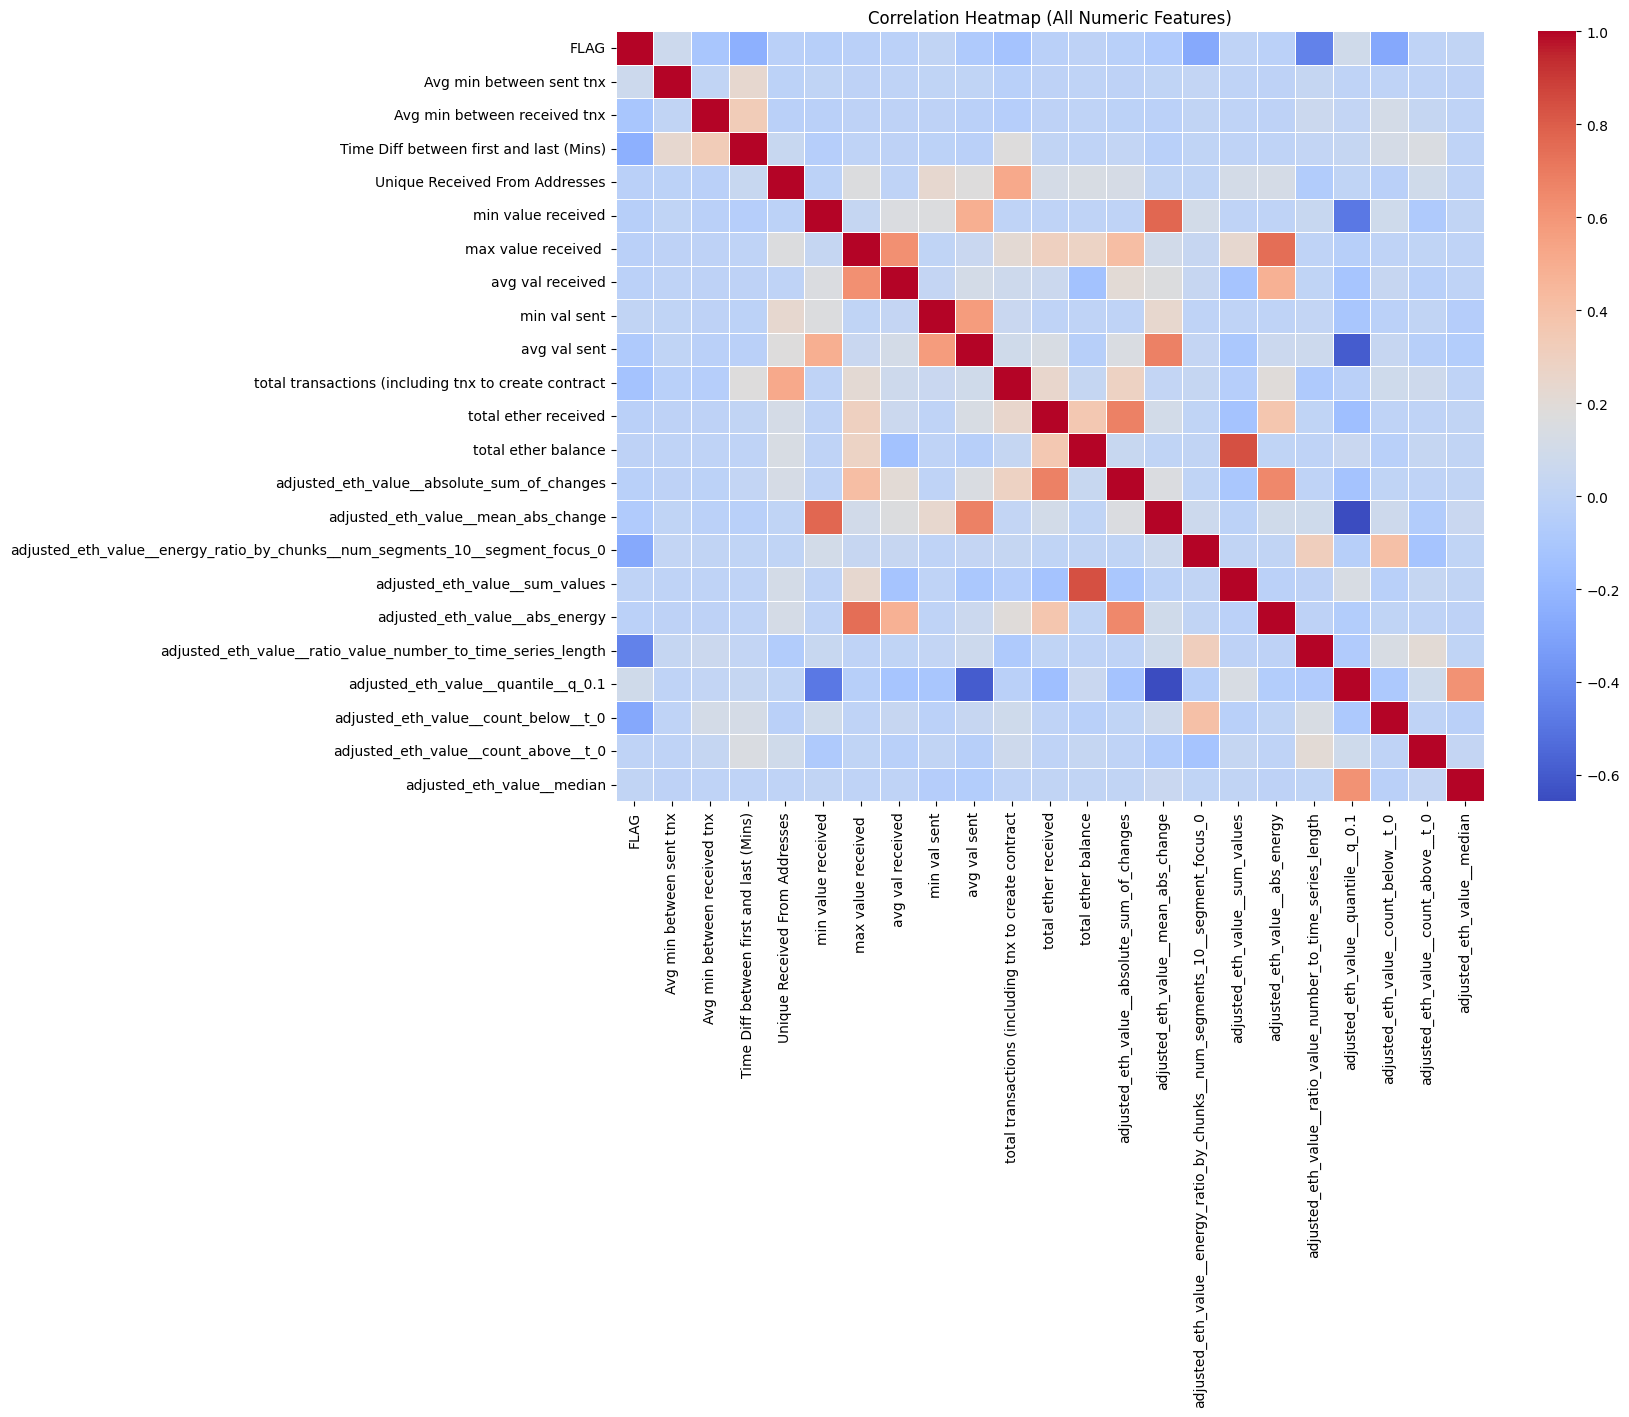

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for numeric columns only
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Heatmap (All Numeric Features)")
plt.show()

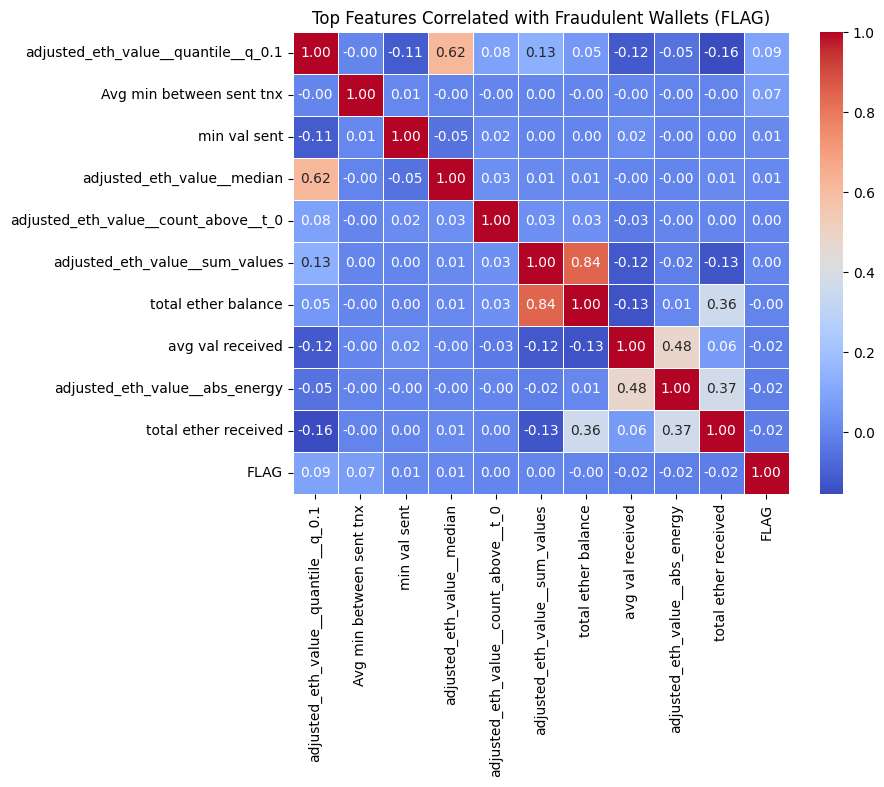

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlations only with the FLAG column
corr_with_flag = df.corr(numeric_only=True)['FLAG'].drop('FLAG').sort_values(ascending=False)

# Select top 10 most correlated features
top_features = corr_with_flag.head(10).index

plt.figure(figsize=(8,6))
sns.heatmap(df[top_features.tolist() + ['FLAG']].corr(),
            cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Top Features Correlated with Fraudulent Wallets (FLAG)")
plt.show()

# **Findings:**
*   Fraudulent wallets show shorter average time between transactions.
*   They receive from a higher number of unique addresses.
*   They have larger max or total Ether values.
*   They display higher adjusted energy ratio in time-series features.

# **Objective 2 & 3: To apply and evaluate the supervised learning models for detecting cryptocurrency wallet fraud using labelled data.**

In [ ]:
'''  '''from sklearn.model_selection import train_test_split
# Drop only the Address column
X = df.drop(columns=['FLAG', 'Address'])
y = df['FLAG']

# Verify that Address is removed
print("Columns in X:", X.columns.tolist())
print("Total columns:", len(X.columns))

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Columns in X: ['Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Unique Received From Addresses', 'min value received', 'max value received ', 'avg val received', 'min val sent', 'avg val sent', 'total transactions (including tnx to create contract', 'total ether received', 'total ether balance', 'adjusted_eth_value__absolute_sum_of_changes', 'adjusted_eth_value__mean_abs_change', 'adjusted_eth_value__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'adjusted_eth_value__sum_values', 'adjusted_eth_value__abs_energy', 'adjusted_eth_value__ratio_value_number_to_time_series_length', 'adjusted_eth_value__quantile__q_0.1', 'adjusted_eth_value__count_below__t_0', 'adjusted_eth_value__count_above__t_0', 'adjusted_eth_value__median']
Total columns: 22


In [ ]:
# 1) show which variable names / shapes are being used
print("X_train variable type:", type(X_train))
try:
    print("X_train shape:", X_train.shape)
    print("X_train columns (first 20):", list(X_train.columns)[:20])
except Exception as e:
    print("Cannot inspect X_train:", e)

# 2) compare columns in X_train with the original df (best verification)
print("Total columns in original df:", df.shape[1])
print("Original df columns (first 20):", list(df.columns)[:20])

X_train variable type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (11136, 22)
X_train columns (first 20): ['Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Unique Received From Addresses', 'min value received', 'max value received ', 'avg val received', 'min val sent', 'avg val sent', 'total transactions (including tnx to create contract', 'total ether received', 'total ether balance', 'adjusted_eth_value__absolute_sum_of_changes', 'adjusted_eth_value__mean_abs_change', 'adjusted_eth_value__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'adjusted_eth_value__sum_values', 'adjusted_eth_value__abs_energy', 'adjusted_eth_value__ratio_value_number_to_time_series_length', 'adjusted_eth_value__quantile__q_0.1', 'adjusted_eth_value__count_below__t_0']
Total columns in original df: 24
Original df columns (first 20): ['Address', 'FLAG', 'Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

lgb = LGBMClassifier(random_state=42)

t0 = time.time()
lgb.fit(X_train, y_train)
t1 = time.time()

y_pred = lgb.predict(X_test)
y_proba = lgb.predict_proba(X_test)[:,1]

print("LightGBM Results")
print("Training time (s):", round(t1 - t0, 3))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5026, number of negative: 6110
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 11136, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.451329 -> initscore=-0.195302
[LightGBM] [Info] Start training from score -0.195302
LightGBM Results
Training time (s): 0.416
Accuracy: 0.9436063218390804
Precision: 0.9372019077901431
Recall: 0.9379474940334129
F1 Score: 0.9375745526838967
AUC: 0.988133511927183


In [ ]:
#get default parameter of LGBM
lgb = LGBMClassifier(random_state=42)
lgb.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# Basic Random Forest using existing X_train / X_test (all-features split)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
rf.fit(X_train, y_train)
t1 = time.time()

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results (all features)")
print("Training time (s):", round(t1 - t0, 3))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

Random Forest Results (all features)
Training time (s): 5.063
Accuracy: 0.9357040229885057
Precision: 0.9270998415213946
Recall: 0.9307875894988067
F1 Score: 0.9289400555776102
AUC: 0.9852983085161862


In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

t0 = time.time()
xgb.fit(X_train, y_train)
t1 = time.time()

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:,1]

print("XGBoost Results")
print("Training time (s):", round(t1 - t0, 3))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:23:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
Training time (s): 2.012
Accuracy: 0.944683908045977
Precision: 0.9373513084853291
Recall: 0.9403341288782816
F1 Score: 0.9388403494837172
AUC: 0.9876172152384107


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

# **Baseline and data prep, using top 10 features only**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

top_features = [
    'adjusted_eth_value__abs_energy',
    'Time Diff between first and last (Mins)',
    'adjusted_eth_value__absolute_sum_of_changes',
    'total ether received',
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'total ether balance',
    'max value received ',
    'adjusted_eth_value__sum_values',
    'total transactions (including tnx to create contract'
]

# Prepare X using only top features
X_top = df.copy()
if 'Address' in X_top.columns:
    X_top = X_top.drop(columns=['Address'])
X_top = X_top[top_features].copy()

y = df['FLAG']

# Train test split using new variable names
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

def print_metrics(name, y_true, y_pred, y_proba=None):
    print(name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    if y_proba is not None:
        print("AUC:", roc_auc_score(y_true, y_proba))
    print("-----------")

# Baseline 1: majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_top, y_train_top)
y_pred_dummy = dummy.predict(X_test_top)
print_metrics("DummyClassifier most_frequent baseline", y_test_top, y_pred_dummy)

# Baseline 2: logistic regression
logr = LogisticRegression(max_iter=1000, random_state=42)
logr.fit(X_train_top, y_train_top)
y_pred_logr = logr.predict(X_test_top)
y_proba_logr = logr.predict_proba(X_test_top)[:, 1]
print_metrics("Logistic Regression baseline", y_test_top, y_pred_logr, y_proba_logr)

DummyClassifier most_frequent baseline
Accuracy: 0.5484913793103449
Precision: 0.0
Recall: 0.0
F1: 0.0
-----------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression baseline
Accuracy: 0.7133620689655172
Precision: 0.8977469670710572
Recall: 0.4120922832140016
F1: 0.5648854961832062
AUC: 0.7644509671836407
-----------


In [ ]:
from lightgbm import LGBMClassifier
import time

lgb_model = LGBMClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
lgb_model.fit(X_train_top, y_train_top)
t1 = time.time()

y_pred = lgb_model.predict(X_test_top)
y_proba = lgb_model.predict_proba(X_test_top)[:, 1]

print("LightGBM Results")
print("Training time (s):", round(t1 - t0, 3))
print_metrics("LightGBM", y_test_top, y_pred, y_proba)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5026, number of negative: 6110
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 11136, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.451329 -> initscore=-0.195302
[LightGBM] [Info] Start training from score -0.195302
LightGBM Results
Training time (s): 0.264
LightGBM
Accuracy: 0.9148706896551724
Precision: 0.9022082018927445
Recall: 0.9101034208432777
F1: 0.9061386138613862
AUC: 0.9745264111024106
-----------


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
rf_model.fit(X_train_top, y_train_top)
t1 = time.time()

y_pred = rf_model.predict(X_test_top)
y_proba = rf_model.predict_proba(X_test_top)[:, 1]

print("Random Forest Results")
print("Training time (s):", round(t1 - t0, 3))
print_metrics("Random Forest", y_test_top, y_pred, y_proba)

Random Forest Results
Training time (s): 4.209
Random Forest
Accuracy: 0.9123563218390804
Precision: 0.9003952569169961
Recall: 0.9061256961018298
F1: 0.9032513877874703
AUC: 0.9720361001313405
-----------


In [ ]:
from xgboost import XGBClassifier
import time

xgb_model = XGBClassifier(
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
xgb_model.fit(X_train_top, y_train_top)
t1 = time.time()

y_pred = xgb_model.predict(X_test_top)
y_proba = xgb_model.predict_proba(X_test_top)[:, 1]

print("XGBoost Results")
print("Training time (s):", round(t1 - t0, 3))
print_metrics("XGBoost", y_test_top, y_pred, y_proba)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:51:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
Training time (s): 0.353
XGBoost
Accuracy: 0.9091235632183908
Precision: 0.8952755905511811
Recall: 0.9045346062052506
F1: 0.8998812821527503
AUC: 0.9721392552719831
-----------


# **Hyperparameter tuning using all features**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Start from full dataframe
df_full = df.copy()

# 2. Remove Address if it exists
if 'Address' in df_full.columns:
    df_full = df_full.drop(columns=['Address'])

# 3. Separate target
y = df_full['FLAG']

# 4. Remove FLAG from feature set
X_all = df_full.drop(columns=['FLAG'])

# 5. Keep only numeric and boolean features to avoid dtype errors
X_all = X_all.select_dtypes(include=['number', 'bool'])

# 6. Create stratified train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features:", X_train.shape[1])
print("Features used:", list(X_train.columns))

X_train shape: (11136, 22)
X_test shape: (2784, 22)
Number of features: 22
Features used: ['Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Unique Received From Addresses', 'min value received', 'max value received ', 'avg val received', 'min val sent', 'avg val sent', 'total transactions (including tnx to create contract', 'total ether received', 'total ether balance', 'adjusted_eth_value__absolute_sum_of_changes', 'adjusted_eth_value__mean_abs_change', 'adjusted_eth_value__energy_ratio_by_chunks__num_segments_10__segment_focus_0', 'adjusted_eth_value__sum_values', 'adjusted_eth_value__abs_energy', 'adjusted_eth_value__ratio_value_number_to_time_series_length', 'adjusted_eth_value__quantile__q_0.1', 'adjusted_eth_value__count_below__t_0', 'adjusted_eth_value__count_above__t_0', 'adjusted_eth_value__median']


In [ ]:
# LightGBM randomized search
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
import time
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# base model
lgb = LGBMClassifier(random_state=42, n_jobs=-1)

# parameter distributions
param_dist = {
    'n_estimators': randint(50, 500),
    'num_leaves': randint(8, 256),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'min_child_samples': randint(5, 200),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.4, 0.6),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# fit and time it
t0 = time.time()
search.fit(X_train, y_train)
t1 = time.time()

print("RandomizedSearchCV time (s):", round(t1 - t0, 2))

# save the best model correctly
lgb_best = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

# evaluate using the correct variable: lgb_best
y_pred = lgb_best.predict(X_test)
y_proba = lgb_best.predict_proba(X_test)[:, 1]

print("Test AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5026, number of negative: 6110
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 11136, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.451329 -> initscore=-0.195302
[LightGBM] [Info] Start training from score -0.195302
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [ ]:
import joblib
joblib.dump(lgb_best, 'lgb_best_all_features.joblib')
print("\nSaved tuned LightGBM to lgb_best_all_features.joblib")


Saved tuned LightGBM to lgb_best_all_features.joblib


In [ ]:
# Random Forest hyperparameter tuning (RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import time, joblib, numpy as np, pandas as pd

# base estimator
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# parameter distributions
param_dist = {
    'n_estimators': randint(100, 800),        # number of trees
    'max_depth': [None] + list(range(5, 41, 5)),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf': randint(1, 50),
    'max_features': ['sqrt', 'log2', None, 0.2, 0.5, 0.8],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# CV and search config
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,                 # set to 10-20 for faster runs
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Run search and time it
t0 = time.time()
search.fit(X_train, y_train)
t1 = time.time()
print("RandomizedSearchCV time (s):", round(t1 - t0, 2))

# Extract best estimator and print results
rf_best = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

# Evaluate on the held-out test set
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

print("\nTest performance (Random Forest tuned)")
print("Test AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))

# Save tuned model
joblib.dump(rf_best, 'rf_best_all_features.joblib')
print("\nSaved tuned Random Forest to rf_best_all_features.joblib")

Fitting 4 folds for each of 30 candidates, totalling 120 fits
RandomizedSearchCV time (s): 2956.16
Best params: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 21, 'n_estimators': 191}
Best CV AUC: 0.9823893644541474

Test performance (Random Forest tuned)
Test AUC: 0.9859
Accuracy: 0.9368
Precision: 0.9273
Recall: 0.9332
F1: 0.9302

Saved tuned Random Forest to rf_best_all_features.joblib


In [ ]:
# XGBoost hyperparameter tuning (RandomizedSearchCV)
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import time, joblib

# base estimator
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

# parameter distributions
param_dist = {
    'n_estimators': randint(50, 600),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.6),
    'colsample_bytree': uniform(0.4, 0.6),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

# CV and search config
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,            # reduce to 10-15 to run faster
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Run search and time it
t0 = time.time()
search.fit(X_train, y_train)
t1 = time.time()
print("RandomizedSearchCV time (s):", round(t1 - t0, 2))

# Extract best estimator and print results
xgb_best = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

# Evaluate on the held-out test set
y_pred = xgb_best.predict(X_test)
y_proba = xgb_best.predict_proba(X_test)[:, 1]

print("\nTest performance (XGBoost tuned)")
print("Test AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
21 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1803, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dis

RandomizedSearchCV time (s): 47.31
Best params: {'colsample_bytree': np.float64(0.916438349953806), 'gamma': np.float64(0.03476065265595352), 'learning_rate': np.float64(0.16322419077326972), 'max_depth': 11, 'n_estimators': 367, 'reg_alpha': np.float64(0.22210781047073025), 'reg_lambda': np.float64(0.1198653673336828), 'subsample': np.float64(0.7025691028421768)}
Best CV AUC: 0.9856918476342104

Test performance (XGBoost tuned)
Test AUC: 0.9886
Accuracy: 0.9429
Precision: 0.9385
Recall: 0.9348
F1: 0.9366


In [ ]:
# Save tuned model
joblib.dump(xgb_best, 'xgb_best_all_features.joblib')
print("\nSaved tuned XGBoost to xgb_best_all_features.joblib")


Saved tuned XGBoost to xgb_best_all_features.joblib


# **Objective 3: To evaluate using SHAP based explanations for tuned LGBM model**

# **SHAP Explanation**

In [ ]:
import joblib

lgb_best = joblib.load('lgb_best_all_features.joblib')

In [ ]:
import shap
explainer = shap.TreeExplainer(lgb_best)
shap_values = explainer.shap_values(X_test)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
print(shap_values)

[[-0.32220117 -0.07585558 -0.11625454 ... -0.29368062 -0.07389205
   0.09598307]
 [ 0.21990957 -1.0191575  -0.20346362 ...  0.04461008 -0.15924159
   0.1271295 ]
 [-0.67631045  0.25091323  0.67740457 ...  0.2783149   0.08415972
   0.1898441 ]
 ...
 [-0.37923627 -0.14804522 -0.21463646 ... -0.14336812 -0.24224121
  -0.2887554 ]
 [ 0.72810262  0.45017047  0.93340967 ... -0.13215939  0.60053965
   0.18984961]
 [ 0.53651862 -0.61003051 -1.36793744 ... -0.02528146  0.23350976
  -0.40683479]]


/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


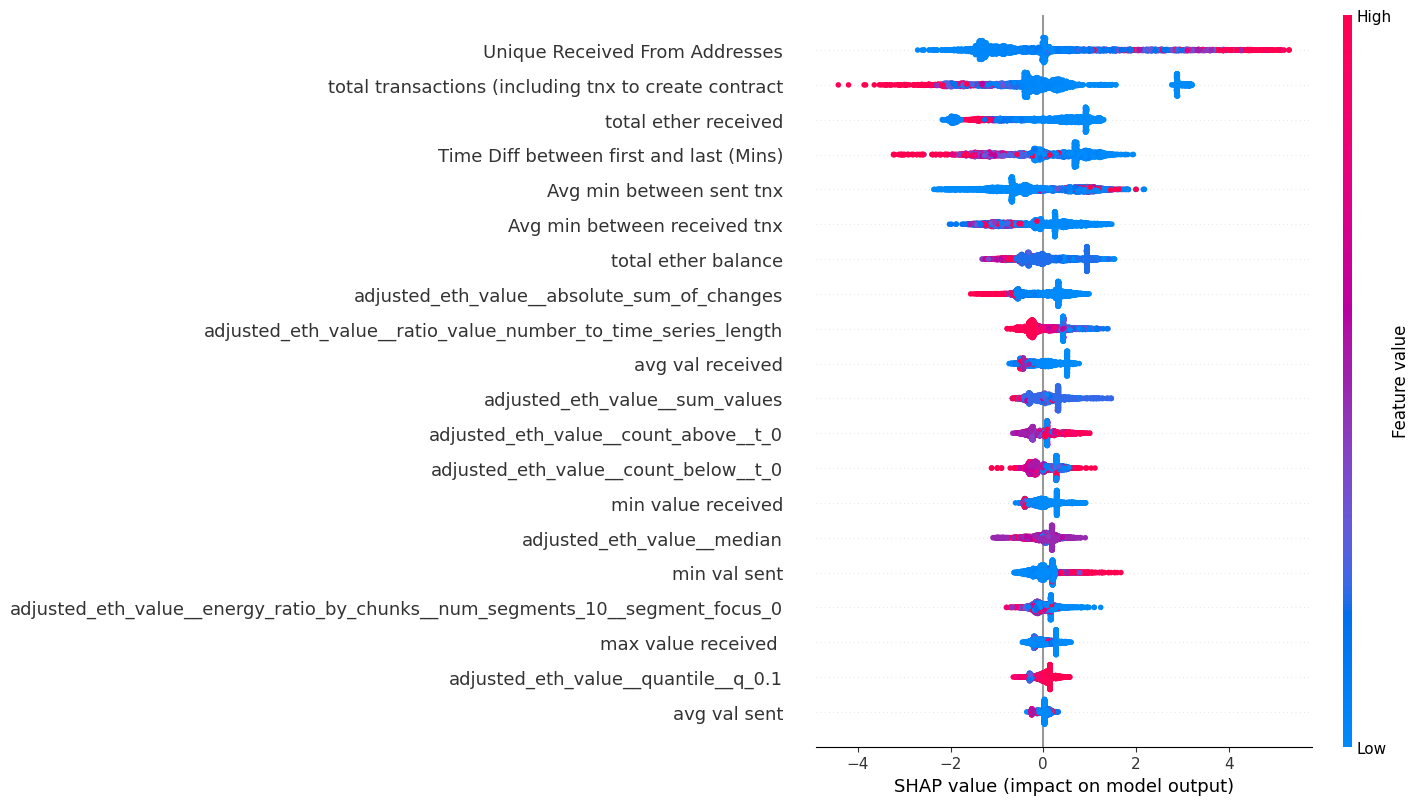

In [ ]:
shap.summary_plot(shap_values, X_test)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


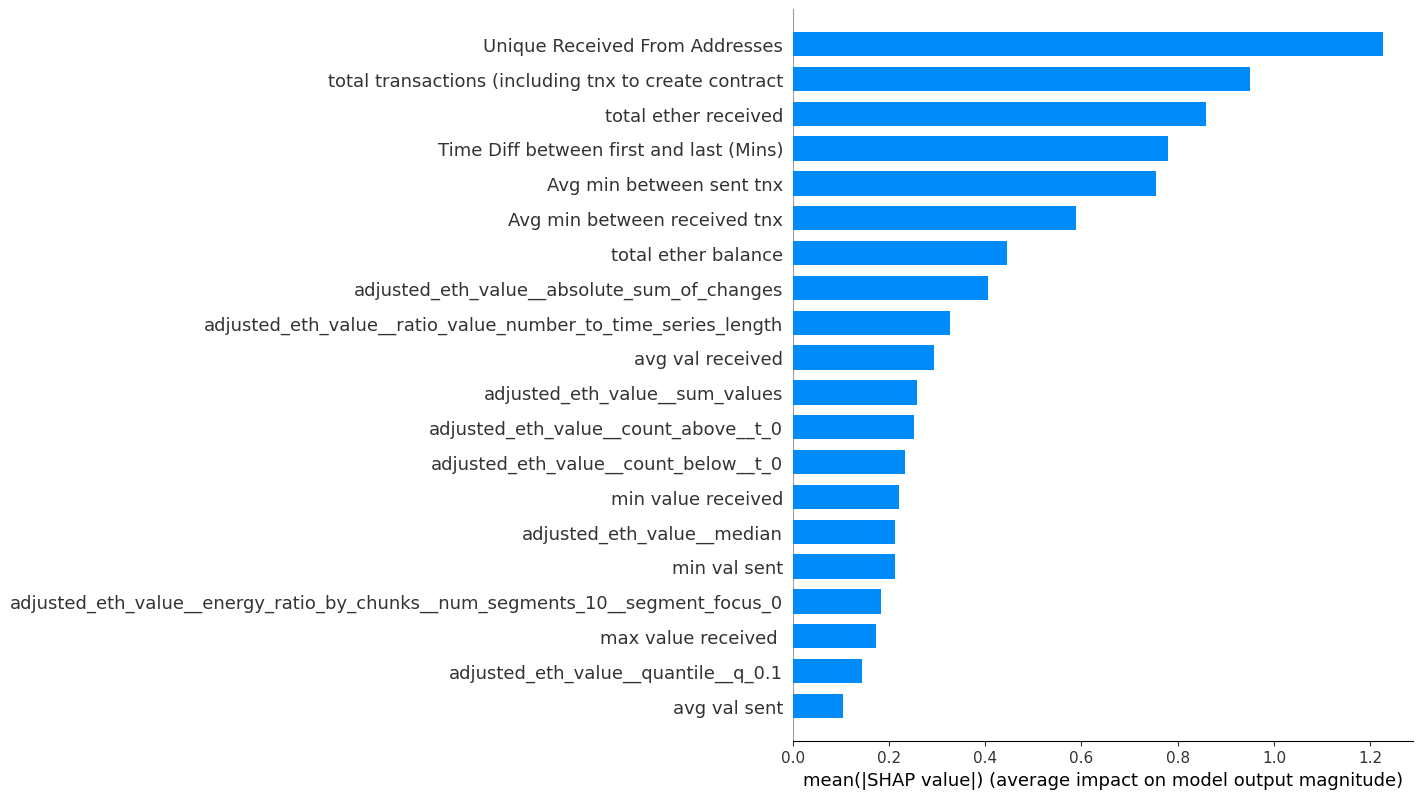

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

# **Objective 2: To apply and evaluate the unsupervised learning models for detecting cryptocurrency wallet fraud using unlabelled data.**
## **1. Isolation Forest**

Using features: 22 columns
IsolationForest fit time (s): 0.62

IsolationForest evaluation (using contamination = 0.45136494252873566 )
Accuracy: 0.4
Precision: 0.3353
Recall: 0.3353
F1: 0.3353
AUC (score ranking): 0.423
Confusion matrix (rows true, cols pred):
 [[3461 4176]
 [4176 2107]]


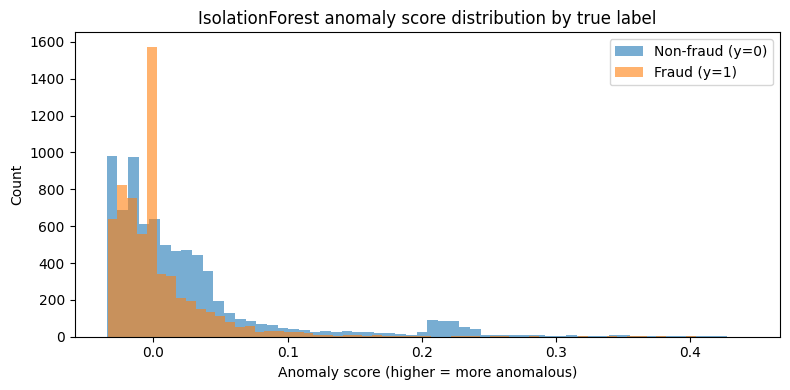


Custom threshold (95th percentile) evaluation
Threshold value: 0.153407
Accuracy: 0.509
Precision: 0.1034
Recall: 0.0115
F1: 0.0206


,true_label,iso_pred,iso_score,custom_pred_95pct
0,1,0,-0.011812,0
1,1,0,-0.021424,0
2,1,0,-0.005850,0
3,1,0,-0.000108,0
4,1,0,-0.004186,0


In [ ]:
# Isolation Forest anomaly detection - full pipeline
# Drop FLAG and Address, scale, train IsolationForest, evaluate vs labels

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# 1) Prepare features X and labels y (drop FLAG and Address)
df_clean = df.copy()
if 'Address' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Address'])
# Ensure FLAG exists
if 'FLAG' not in df_clean.columns:
    raise ValueError("FLAG column not found in df")
y = df_clean['FLAG'].astype(int).values
X_all = df_clean.drop(columns=['FLAG'])

# 2) Keep only numeric/boolean columns to avoid dtype issues
X_all = X_all.select_dtypes(include=['number', 'bool'])
print("Using features:", X_all.shape[1], "columns")

# 3) Scale features (recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# 4) Train IsolationForest
# Option A: set contamination to the known fraud rate (only for evaluation convenience)
contamination = y.mean()          # e.g., 0.46 from your dataset; this helps thresholding
# Option B: 'auto' (or leave default) if you don't want to use label info even as an estimate
# contamination = 'auto'

iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42, n_jobs=-1)

t0 = time.time()
iso.fit(X_scaled)   # unsupervised - does not use y
t1 = time.time()
print("IsolationForest fit time (s):", round(t1 - t0, 3))

# 5) Get anomaly scores and predicted labels
# sklearn's predict: -1 = anomaly, 1 = normal
pred_raw = iso.predict(X_scaled)
anomaly_pred = np.where(pred_raw == -1, 1, 0)   # 1 = anomaly (fraud), 0 = normal

# anomaly_score: higher means more normal by default (decision_function), so invert for "anomalyness"
scores = -iso.decision_function(X_scaled)  # now higher score -> more anomalous

# 6) Evaluate predictions against true labels y
acc = accuracy_score(y, anomaly_pred)
prec = precision_score(y, anomaly_pred, zero_division=0)
rec = recall_score(y, anomaly_pred, zero_division=0)
f1 = f1_score(y, anomaly_pred, zero_division=0)
auc = roc_auc_score(y, scores)   # using anomaly score as "probability" ranking

print("\nIsolationForest evaluation (using contamination =", contamination, ")")
print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))
print("AUC (score ranking):", round(auc,4))
print("Confusion matrix (rows true, cols pred):\n", confusion_matrix(y, anomaly_pred))

# 7) Inspect score distribution and optional thresholding
plt.figure(figsize=(8,4))
plt.hist(scores[y==0], bins=60, alpha=0.6, label='Non-fraud (y=0)')
plt.hist(scores[y==1], bins=60, alpha=0.6, label='Fraud (y=1)')
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.title('IsolationForest anomaly score distribution by true label')
plt.tight_layout()
plt.show()

# 8) Optional: choose a custom threshold instead of predict labels from iso.predict
# For example choose threshold at 95th percentile of scores to declare anomalies
th = np.percentile(scores, 95)   # change percentile as you like
custom_pred = (scores >= th).astype(int)   # 1 = anomaly
print("\nCustom threshold (95th percentile) evaluation")
print("Threshold value:", round(th,6))
print("Accuracy:", round(accuracy_score(y, custom_pred),4))
print("Precision:", round(precision_score(y, custom_pred, zero_division=0),4))
print("Recall:", round(recall_score(y, custom_pred, zero_division=0),4))
print("F1:", round(f1_score(y, custom_pred, zero_division=0),4))

# 9) Save results into dataframe for inspection
results_df = pd.DataFrame({
    'true_label': y,
    'iso_pred': anomaly_pred,
    'iso_score': scores
})
results_df['custom_pred_95pct'] = custom_pred

results_df.head()

Attempt 1 -
Isolation Forest on top 10 features with contamination = 0.1

Using features: 10 columns
IsolationForest fit time (s): 0.603

IsolationForest (top10, contamination=0.1) evaluation
Contamination used: 0.1
Accuracy: 0.4884
Precision: 0.199
Recall: 0.0441
F1: 0.0722
AUC (score ranking): 0.2734
Confusion matrix (rows true, cols pred):
 [[6522 1115]
 [6006  277]]


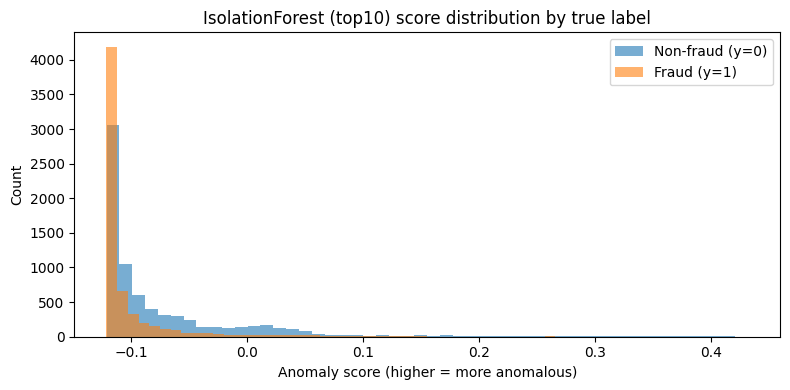

,true_label,iso_pred,iso_score,model
0,1,0,-0.103392,iso_top10_cont0.1
1,1,0,-0.118992,iso_top10_cont0.1
2,1,0,-0.121275,iso_top10_cont0.1
3,1,0,-0.120738,iso_top10_cont0.1
4,1,0,-0.110336,iso_top10_cont0.1


In [ ]:
# Step 1: IsolationForest on top-10 features, contamination=0.1
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# Top features list (make sure it matches your column names)
top_features = [
    'adjusted_eth_value__abs_energy',
    'Time Diff between first and last (Mins)',
    'adjusted_eth_value__absolute_sum_of_changes',
    'total ether received',
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'total ether balance',
    'max value received ',
    'adjusted_eth_value__sum_values',
    'total transactions (including tnx to create contract'
]

# 1) Prepare X_top and y
df_top = df.copy()
if 'Address' in df_top.columns:
    df_top = df_top.drop(columns=['Address'])
if 'FLAG' not in df_top.columns:
    raise ValueError("FLAG column not found in df")
y = df_top['FLAG'].astype(int).values

# Keep only the specified top features
X_top = df_top[top_features].copy()

# 2) Keep numeric columns only (just in case) and report shape
X_top = X_top.select_dtypes(include=['number', 'bool'])
print("Using features:", X_top.shape[1], "columns")

# 3) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# 4) Fit IsolationForest with contamination = 0.1
contamination_value = 0.1
iso = IsolationForest(n_estimators=200, contamination=contamination_value, random_state=42, n_jobs=-1)

t0 = time.time()
iso.fit(X_scaled)   # unsupervised
t1 = time.time()
print("IsolationForest fit time (s):", round(t1 - t0, 3))

# 5) Predictions and scores
pred_raw = iso.predict(X_scaled)            # -1 anomaly, 1 normal
iso_pred = np.where(pred_raw == -1, 1, 0)  # 1 = anomaly, 0 = normal
scores = -iso.decision_function(X_scaled)  # higher = more anomalous

# 6) Metrics
acc = accuracy_score(y, iso_pred)
prec = precision_score(y, iso_pred, zero_division=0)
rec = recall_score(y, iso_pred, zero_division=0)
f1 = f1_score(y, iso_pred, zero_division=0)
auc = roc_auc_score(y, scores)

print("\nIsolationForest (top10, contamination=0.1) evaluation")
print("Contamination used:", contamination_value)
print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))
print("AUC (score ranking):", round(auc,4))
print("Confusion matrix (rows true, cols pred):\n", confusion_matrix(y, iso_pred))

# 7) Plot score distributions by true label
plt.figure(figsize=(8,4))
plt.hist(scores[y==0], bins=50, alpha=0.6, label='Non-fraud (y=0)')
plt.hist(scores[y==1], bins=50, alpha=0.6, label='Fraud (y=1)')
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.title('IsolationForest (top10) score distribution by true label')
plt.tight_layout()
plt.show()

# 8) Save results for inspection
results_iso_top10 = pd.DataFrame({
    'true_label': y,
    'iso_pred': iso_pred,
    'iso_score': scores
})
results_iso_top10['model'] = 'iso_top10_cont0.1'
results_iso_top10.head()

Attempt 2 — PCA on scaled top-10 features, then Isolation Forest (contamination = 0.1)

PCA components shape: (13920, 8)
Explained variance ratio sum: 0.9849
IsolationForest (PCA) fit time (s): 0.87

IsolationForest (PCA + top10, contamination=0.1) evaluation
Accuracy: 0.5011
Precision: 0.2622
Recall: 0.0581
F1: 0.0951
AUC (score ranking): 0.3498
Confusion matrix (rows true, cols pred):
 [[6610 1027]
 [5918  365]]


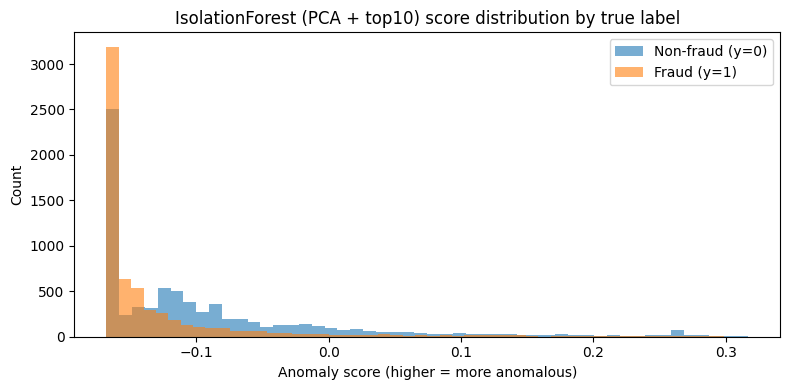

,true_label,iso_pred_pca,iso_score_pca,model
0,1,0,-0.114120,iso_top10_pca_cont0.1
1,1,0,-0.162254,iso_top10_pca_cont0.1
2,1,0,-0.165234,iso_top10_pca_cont0.1
3,1,0,-0.167547,iso_top10_pca_cont0.1
4,1,0,-0.139192,iso_top10_pca_cont0.1


In [ ]:
# Step 2: PCA + IsolationForest on top-10 features, contamination=0.1
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# Reuse X_top and y from step 1 (if not available, recreate as above)
# X_top, y already exist if you ran the previous block; otherwise recreate them.

# 1) Scale (if not already scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# 2) Apply PCA (keep 95% variance or set n_components=5-8)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("PCA components shape:", X_pca.shape)
print("Explained variance ratio sum:", round(pca.explained_variance_ratio_.sum(),4))

# 3) Fit IsolationForest on PCA-transformed data
contamination_value = 0.1
iso_pca = IsolationForest(n_estimators=200, contamination=contamination_value, random_state=42, n_jobs=-1)

t0 = time.time()
iso_pca.fit(X_pca)
t1 = time.time()
print("IsolationForest (PCA) fit time (s):", round(t1 - t0, 3))

# 4) Predictions and scores
pred_raw_pca = iso_pca.predict(X_pca)
iso_pred_pca = np.where(pred_raw_pca == -1, 1, 0)
scores_pca = -iso_pca.decision_function(X_pca)

# 5) Metrics
acc_pca = accuracy_score(y, iso_pred_pca)
prec_pca = precision_score(y, iso_pred_pca, zero_division=0)
rec_pca = recall_score(y, iso_pred_pca, zero_division=0)
f1_pca = f1_score(y, iso_pred_pca, zero_division=0)
auc_pca = roc_auc_score(y, scores_pca)

print("\nIsolationForest (PCA + top10, contamination=0.1) evaluation")
print("Accuracy:", round(acc_pca,4))
print("Precision:", round(prec_pca,4))
print("Recall:", round(rec_pca,4))
print("F1:", round(f1_pca,4))
print("AUC (score ranking):", round(auc_pca,4))
print("Confusion matrix (rows true, cols pred):\n", confusion_matrix(y, iso_pred_pca))

# 6) Plot score distributions by true label
plt.figure(figsize=(8,4))
plt.hist(scores_pca[y==0], bins=50, alpha=0.6, label='Non-fraud (y=0)')
plt.hist(scores_pca[y==1], bins=50, alpha=0.6, label='Fraud (y=1)')
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.title('IsolationForest (PCA + top10) score distribution by true label')
plt.tight_layout()
plt.show()

# 7) Save results for inspection
results_iso_pca = pd.DataFrame({
    'true_label': y,
    'iso_pred_pca': iso_pred_pca,
    'iso_score_pca': scores_pca
})
results_iso_pca['model'] = 'iso_top10_pca_cont0.1'
results_iso_pca.head()

## **2. DBSCAN**

Using features: 10

DBSCAN (eps=0.5, min_samples=10) Results
Accuracy: 0.5386
Precision: 0.3624
Recall: 0.0291
F1: 0.0539
AUC: 0.4935

Confusion Matrix (rows=actual, cols=predicted):
 [[7315  322]
 [6100  183]]

DBSCAN cluster summary:
Unique clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
Number of noise points (-1): 505
Number of clustered points: 13415


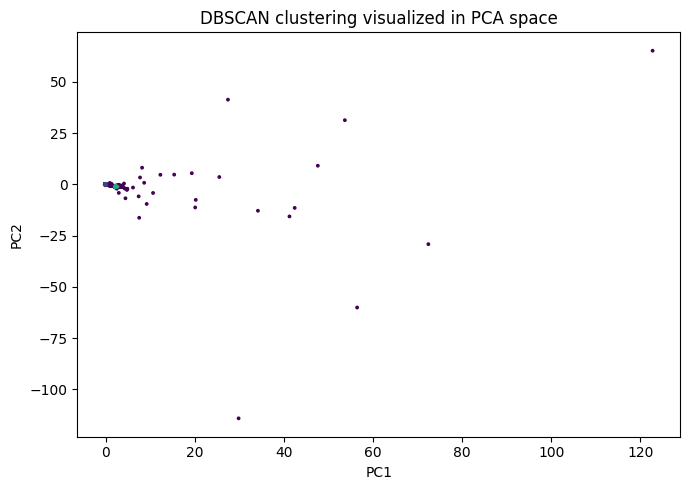

,true_label,dbscan_pred,cluster_label
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [ ]:
# DBSCAN anomaly detection - full pipeline
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------
# 1. Prepare X_top and y (top 10 features)
# -------------------------------------
top_features = [
    'adjusted_eth_value__abs_energy',
    'Time Diff between first and last (Mins)',
    'adjusted_eth_value__absolute_sum_of_changes',
    'total ether received',
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'total ether balance',
    'max value received ',
    'adjusted_eth_value__sum_values',
    'total transactions (including tnx to create contract'
]

df_top = df.copy()

# Drop address if present
if 'Address' in df_top.columns:
    df_top = df_top.drop(columns=['Address'])

# Extract labels
y = df_top['FLAG'].astype(int).values

# Extract only top 10 features
X_top = df_top[top_features].copy()
X_top = X_top.select_dtypes(include=['number', 'bool'])
print("Using features:", X_top.shape[1])

# -------------------------------------
# 2. Standardize features (CRITICAL for DBSCAN)
# -------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# -------------------------------------
# 3. Run DBSCAN
# Start with eps=0.5, min_samples=10
# -------------------------------------
dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
cluster_labels = dbscan.fit_predict(X_scaled)

# DBSCAN outputs cluster labels:
#   -1 = noise (treated as anomaly)
#    0,1,2.. = cluster groups (normal)
anomaly_pred = np.where(cluster_labels == -1, 1, 0)

# -------------------------------------
# 4. Evaluate against true fraud labels
# -------------------------------------
acc = accuracy_score(y, anomaly_pred)
prec = precision_score(y, anomaly_pred, zero_division=0)
rec = recall_score(y, anomaly_pred, zero_division=0)
f1 = f1_score(y, anomaly_pred, zero_division=0)

# For AUC: need an "anomaly score"
# Use: anomaly_score = 1 for noise points, 0 for cluster points
anomaly_score = anomaly_pred.astype(float)
auc = roc_auc_score(y, anomaly_score)

print("\nDBSCAN (eps=0.5, min_samples=10) Results")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1:", round(f1, 4))
print("AUC:", round(auc, 4))
print("\nConfusion Matrix (rows=actual, cols=predicted):\n", confusion_matrix(y, anomaly_pred))

# -------------------------------------
# 5. Count clusters
# -------------------------------------
unique_clusters = set(cluster_labels)
print("\nDBSCAN cluster summary:")
print("Unique clusters:", unique_clusters)
print("Number of noise points (-1):", sum(cluster_labels == -1))
print("Number of clustered points:", sum(cluster_labels != -1))

# -------------------------------------
# 6. Plot cluster assignment (optional)
# Reduce to 2D for visualisation using PCA
# -------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_points = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(
    pca_points[:,0],
    pca_points[:,1],
    c=cluster_labels,
    cmap='viridis',
    s=3
)
plt.title("DBSCAN clustering visualized in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# -------------------------------------
# 7. Return results
# -------------------------------------
results_dbscan = pd.DataFrame({
    'true_label': y,
    'dbscan_pred': anomaly_pred,
    'cluster_label': cluster_labels
})
results_dbscan.head()

## **3.  Autoencoder**

Using features: 10

OPTION A: Train autoencoder on ALL data (unsupervised)

Epoch 1/100
98/98 - 5s - 52ms/step - loss: 0.9107 - val_loss: 0.0146
Epoch 2/100
98/98 - 1s - 9ms/step - loss: 0.5789 - val_loss: 0.0040
Epoch 3/100
98/98 - 1s - 6ms/step - loss: 0.4139 - val_loss: 0.0034
Epoch 4/100
98/98 - 1s - 6ms/step - loss: 0.2865 - val_loss: 0.0025
Epoch 5/100
98/98 - 1s - 5ms/step - loss: 0.2231 - val_loss: 0.0016
Epoch 6/100
98/98 - 1s - 9ms/step - loss: 0.1932 - val_loss: 0.0011
Epoch 7/100
98/98 - 1s - 12ms/step - loss: 0.1670 - val_loss: 0.0014
Epoch 8/100
98/98 - 2s - 19ms/step - loss: 0.1496 - val_loss: 0.0012
Epoch 9/100
98/98 - 1s - 11ms/step - loss: 0.1318 - val_loss: 0.0026
Epoch 10/100
98/98 - 1s - 14ms/step - loss: 0.1100 - val_loss: 0.0016
Epoch 11/100
98/98 - 1s - 9ms/step - loss: 0.0764 - val_loss: 0.0026
Epoch 12/100
98/98 - 1s - 11ms/step - loss: 0.0699 - val_loss: 0.0017
Epoch 13/100
98/98 - 1s - 5ms/step - loss: 0.1782 - val_loss: 9.5511e-04
Epoch 14/100
98/98 - 1s - 

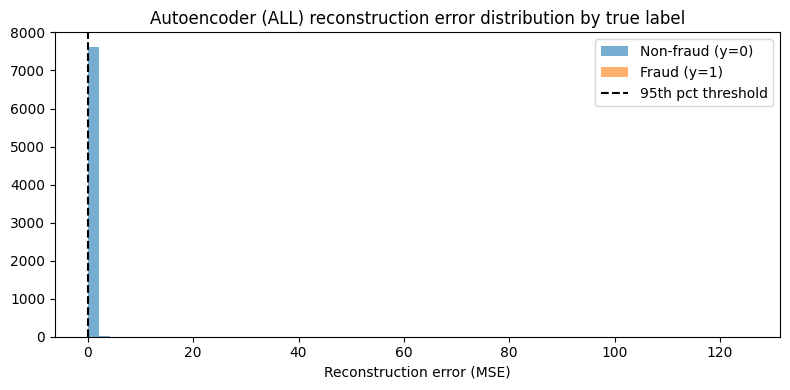


OPTION B: Train autoencoder on NON-FRAUD only (semi-supervised)

Training samples (non-fraud): 7637
Epoch 1/100
54/54 - 4s - 82ms/step - loss: 1.4879 - val_loss: 0.1771
Epoch 2/100
54/54 - 1s - 19ms/step - loss: 1.1027 - val_loss: 0.0806
Epoch 3/100
54/54 - 0s - 7ms/step - loss: 0.7899 - val_loss: 0.0596
Epoch 4/100
54/54 - 0s - 6ms/step - loss: 0.5547 - val_loss: 0.0284
Epoch 5/100
54/54 - 1s - 12ms/step - loss: 0.3839 - val_loss: 0.0258
Epoch 6/100
54/54 - 1s - 12ms/step - loss: 0.2902 - val_loss: 0.0328
Epoch 7/100
54/54 - 1s - 16ms/step - loss: 0.2342 - val_loss: 0.0208
Epoch 8/100
54/54 - 0s - 5ms/step - loss: 0.1776 - val_loss: 0.0180
Epoch 9/100
54/54 - 0s - 5ms/step - loss: 0.1502 - val_loss: 0.0165
Epoch 10/100
54/54 - 0s - 6ms/step - loss: 0.1300 - val_loss: 0.0170
Epoch 11/100
54/54 - 0s - 6ms/step - loss: 0.0961 - val_loss: 0.0155
Epoch 12/100
54/54 - 0s - 6ms/step - loss: 0.0681 - val_loss: 0.0158
Epoch 13/100
54/54 - 1s - 9ms/step - loss: 0.0613 - val_loss: 0.0146
Epoch 

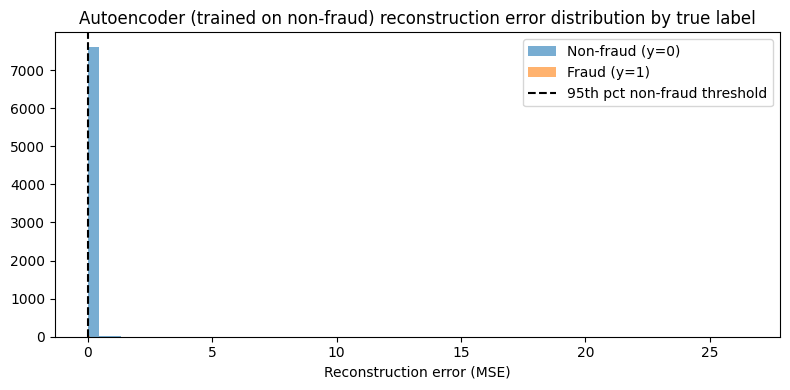

,model,accuracy,precision,recall,f1,auc
0,ae_all,0.527802,0.291667,0.032309,0.058175,0.428822
1,ae_nonfraud,0.536853,0.363333,0.034697,0.063344,0.433453



Saved autoencoder models: ae_all_model.h5, ae_nonfraud_model.h5


In [ ]:
# Autoencoder anomaly detection - two approaches (unsupervised on all / semi-supervised on non-fraud)
# Uses top 10 features, StandardScaler, Keras autoencoder, reconstruction error as anomaly score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

BATCH_SIZE = 128
EPOCHS = 100
PATIENCE = 8
LATENT_DIM = 8   # small network for 10 features
VAL_SPLIT = 0.1
THRESH_PERCENTILE = 95  # percentile on reconstruction error to mark anomaly (can tune)
# ----------------------------------

# 1) Prepare data (drop Address and FLAG, keep only top features)
df_top = df.copy()
if 'Address' in df_top.columns:
    df_top = df_top.drop(columns=['Address'])
if 'FLAG' not in df_top.columns:
    raise ValueError("FLAG column not found in df")
y = df_top['FLAG'].astype(int).values
X_top = df_top[top_features].copy()
X_top = X_top.select_dtypes(include=['number', 'bool'])
print("Using features:", X_top.shape[1])

# 2) Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# Helper: build autoencoder model
def build_autoencoder(input_dim, latent_dim=8):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(32, activation='relu')(latent)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='mse')
    return model

# Utility: compute per-sample reconstruction MSE
def recon_errors(model, X):
    X_pred = model.predict(X, verbose=0)
    errors = np.mean(np.square(X - X_pred), axis=1)
    return errors

# EarlyStopping callback
es = callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# -----------------------
# OPTION A: Train on ALL data (unsupervised)
# -----------------------
print("\nOPTION A: Train autoencoder on ALL data (unsupervised)\n")
ae_all = build_autoencoder(input_dim=X_scaled.shape[1], latent_dim=LATENT_DIM)

t0 = time.time()
history_all = ae_all.fit(
    X_scaled, X_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[es],
    verbose=2
)
t1 = time.time()
print("Training time (s):", round(t1 - t0, 2))

# reconstruction errors and threshold
errors_all = recon_errors(ae_all, X_scaled)
th_all = np.percentile(errors_all, THRESH_PERCENTILE)
pred_all = (errors_all >= th_all).astype(int)  # 1 = anomaly

# metrics using true labels y
acc = accuracy_score(y, pred_all)
prec = precision_score(y, pred_all, zero_division=0)
rec = recall_score(y, pred_all, zero_division=0)
f1 = f1_score(y, pred_all, zero_division=0)
auc = roc_auc_score(y, errors_all)   # higher error => more anomalous
print("\nAutoencoder ALL-data evaluation (threshold = {:.6g} at {}th pct)".format(th_all, THRESH_PERCENTILE))
print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))
print("AUC:", round(auc,4))
print("Confusion matrix (rows true, cols pred):\n", confusion_matrix(y, pred_all))

plt.figure(figsize=(8,4))
plt.hist(errors_all[y==0], bins=60, alpha=0.6, label='Non-fraud (y=0)')
plt.hist(errors_all[y==1], bins=60, alpha=0.6, label='Fraud (y=1)')
plt.axvline(th_all, color='k', linestyle='--', label=f'{THRESH_PERCENTILE}th pct threshold')
plt.legend()
plt.xlabel('Reconstruction error (MSE)')
plt.title('Autoencoder (ALL) reconstruction error distribution by true label')
plt.tight_layout()
plt.show()

# Save results
results_ae_all = pd.DataFrame({
    'true_label': y,
    'ae_all_pred': pred_all,
    'ae_all_error': errors_all
})
results_ae_all['model'] = 'ae_all'

# -----------------------
# OPTION B: Train on NON-FRAUD only (semi-supervised) - recommended
# -----------------------
print("\nOPTION B: Train autoencoder on NON-FRAUD only (semi-supervised)\n")
X_nonfraud = X_scaled[y == 0]
print("Training samples (non-fraud):", X_nonfraud.shape[0])

ae_nf = build_autoencoder(input_dim=X_scaled.shape[1], latent_dim=LATENT_DIM)

t0 = time.time()
history_nf = ae_nf.fit(
    X_nonfraud, X_nonfraud,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[es],
    verbose=2
)
t1 = time.time()
print("Training time (s):", round(t1 - t0, 2))

# reconstruction errors for whole dataset using model trained on non-fraud
errors_nf = recon_errors(ae_nf, X_scaled)

# threshold chosen on non-fraud training errors (e.g., 95th percentile of non-fraud errors)
errors_nf_train = recon_errors(ae_nf, X_nonfraud)
th_nf = np.percentile(errors_nf_train, THRESH_PERCENTILE)
pred_nf = (errors_nf >= th_nf).astype(int)

# metrics
acc_nf = accuracy_score(y, pred_nf)
prec_nf = precision_score(y, pred_nf, zero_division=0)
rec_nf = recall_score(y, pred_nf, zero_division=0)
f1_nf = f1_score(y, pred_nf, zero_division=0)
auc_nf = roc_auc_score(y, errors_nf)

print("\nAutoencoder NON-FRAUD-only evaluation (threshold = {:.6g} on non-fraud train errors)".format(th_nf))
print("Accuracy:", round(acc_nf,4))
print("Precision:", round(prec_nf,4))
print("Recall:", round(rec_nf,4))
print("F1:", round(f1_nf,4))
print("AUC:", round(auc_nf,4))
print("Confusion matrix (rows true, cols pred):\n", confusion_matrix(y, pred_nf))

plt.figure(figsize=(8,4))
plt.hist(errors_nf[y==0], bins=60, alpha=0.6, label='Non-fraud (y=0)')
plt.hist(errors_nf[y==1], bins=60, alpha=0.6, label='Fraud (y=1)')
plt.axvline(th_nf, color='k', linestyle='--', label=f'{THRESH_PERCENTILE}th pct non-fraud threshold')
plt.legend()
plt.xlabel('Reconstruction error (MSE)')
plt.title('Autoencoder (trained on non-fraud) reconstruction error distribution by true label')
plt.tight_layout()
plt.show()

# Save results
results_ae_nf = pd.DataFrame({
    'true_label': y,
    'ae_nf_pred': pred_nf,
    'ae_nf_error': errors_nf
})
results_ae_nf['model'] = 'ae_nonfraud'

# ---------------
# Quick comparison summary
# ---------------
summary = pd.DataFrame({
    'model': ['ae_all','ae_nonfraud'],
    'accuracy': [acc, acc_nf],
    'precision': [prec, prec_nf],
    'recall': [rec, rec_nf],
    'f1': [f1, f1_nf],
    'auc': [auc, auc_nf]
})
display(summary)

# Save models for later
ae_all.save('ae_all_model.h5')
ae_nf.save('ae_nonfraud_model.h5')
print("\nSaved autoencoder models: ae_all_model.h5, ae_nonfraud_model.h5")

# results dataframes available: results_ae_all, results_ae_nf